# Analisis Heuristik & Eksperimen EDA (Exploratory Data Analysis)
### Topik: Optimasi Rute Pengiriman Barang Multi-Drop (Bebas Arah)

Notebook ini berisi analisis tahap awal (EDA) dari dataset pengiriman, konstruksi complete graph, perhitungan matriks jarak, serta pembuktian validitas fungsi heuristik Euclidean untuk algoritma **A* Search** dan **Greedy Best-First Search**.

## 1. Exploratory Data Analysis (EDA)
Pada tahap ini, kita akan memuat data titik pengiriman (`locations.csv`) ke dalam pandas DataFrame untuk memeriksa koordinat $X, Y$ serta beban permintaan (*demand*) paket di tiap lokasi.

In [1]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Tambahkan path parent folder agar module src bisa di-import
sys.path.insert(0, os.path.abspath('..'))

# Load dataset
df = pd.read_csv('../data/raw/locations.csv')
df

,id,name,type,x,y,demand
0,0,Depot,depot,50.00,50.00,0
1,1,Drop-1,drop_point,63.94,2.50,3
2,2,Drop-2,drop_point,24.49,13.95,1
3,3,Drop-3,drop_point,67.67,89.22,1
4,4,Drop-4,drop_point,59.05,3.18,1
5,5,Drop-5,drop_point,21.86,50.54,1
6,6,Drop-6,drop_point,56.12,71.60,5
7,7,Drop-7,drop_point,41.95,44.92,3
8,8,Drop-8,drop_point,80.94,0.65,2


In [2]:
# Tampilkan statistik deskriptif dari sebaran lokasi dan demand
print("=== Statistik Deskriptif ===")
print(df.describe())

print("\n=== Info Tipe Data ===")
print(df.info())

print("\n=== Jumlah Tipe Lokasi ===")
print(df['type'].value_counts())

=== Statistik Deskriptif ===
             id          x          y    demand
count  9.000000   9.000000   9.000000  9.000000
mean   4.000000  51.780000  36.284444  1.888889
std    2.738613  19.564316  32.636647  1.536591
min    0.000000  21.860000   0.650000  0.000000
25%    2.000000  41.950000   3.180000  1.000000
50%    4.000000  56.120000  44.920000  1.000000
75%    6.000000  63.940000  50.540000  3.000000
max    8.000000  80.940000  89.220000  5.000000

=== Info Tipe Data ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   id      9 non-null      int64  
 1   name    9 non-null      object 
 2   type    9 non-null      object 
 3   x       9 non-null      float64
 4   y       9 non-null      float64
 5   demand  9 non-null      int64  
dtypes: float64(2), int64(2), object(2)
memory usage: 564.0+ bytes
None

=== Jumlah Tipe Lokasi ===
type
drop_point    

## 2. Graph Construction & Visualisasi
Kita akan menggunakan modul `DeliveryGraph` yang membungkus `networkx` untuk membangun jaringan lengkap (*complete graph*) di mana setiap node terhubung ke node lainnya.

In [3]:
from src.graph import build_graph_from_csv
from src.visualization import plot_locations, plot_full_graph, plot_distance_heatmap

# Bangun DeliveryGraph
g = build_graph_from_csv('../data/raw/locations.csv')
print(f"Jumlah Node : {len(g.all_node_ids())}")
print(f"ID Depot    : {g.depot_id}")
print(f"Drop Points : {g.drop_point_ids()}")

Jumlah Node : 9
ID Depot    : 0
Drop Points : [1, 2, 3, 4, 5, 6, 7, 8]


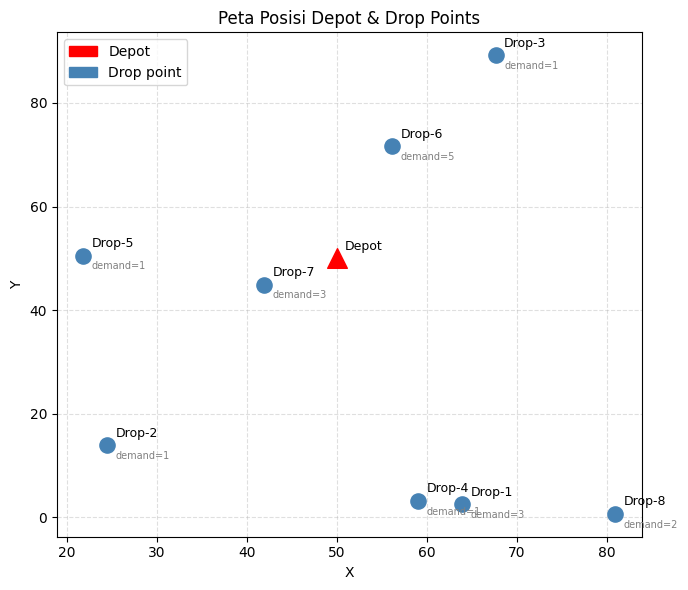

In [4]:
# Visualisasi posisi Depot dan Drop Points
fig_loc = plot_locations(g, title="Peta Posisi Depot & Drop Points")
plt.show()

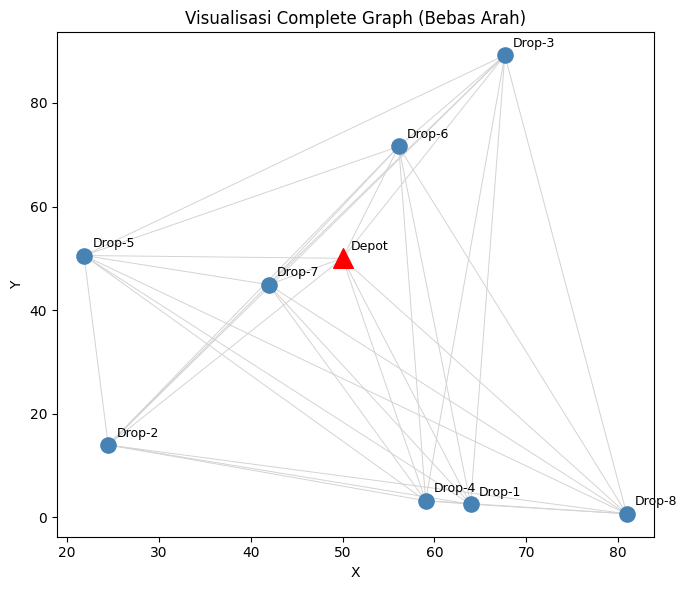

In [5]:
# Visualisasi Complete Graph (Semua Edge Terhubung)
fig_full = plot_full_graph(g, title="Visualisasi Complete Graph (Bebas Arah)")
plt.show()

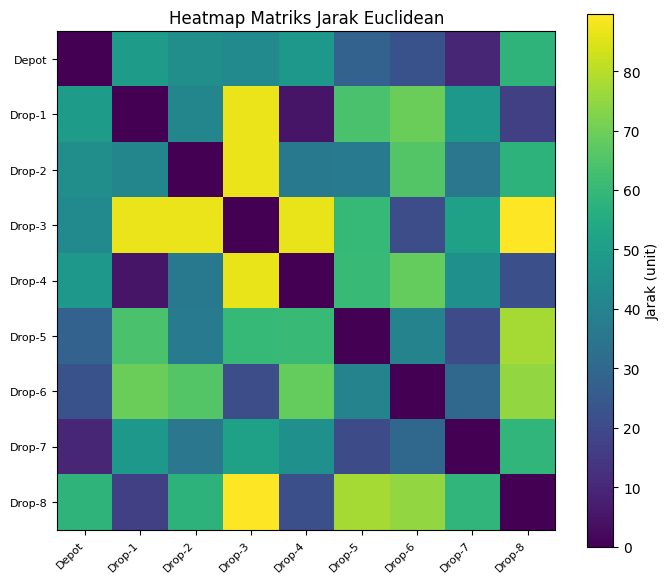

In [6]:
# Tampilkan heatmap matriks jarak Euclidean antar semua titik
fig_heat = plot_distance_heatmap(g, title="Heatmap Matriks Jarak Euclidean")
plt.show()

## 3. Pembuktian Validitas Heuristik (Admissibility & Consistency)

Agar algoritma **A* Search** dapat menghasilkan rute yang **optimal secara absolut** (jarak terpendek), fungsi heuristik $h(n)$ yang digunakan wajib memenuhi dua syarat:
1. **Admissible (Layak)**: $h(n) \le h^*(n)$ di mana $h^*(n)$ adalah biaya asli dari $n$ ke tujuan.
   - *Bukti*: Karena pergerakan diasumsikan bebas arah di ruang 2D, jarak terpendek matematis antara dua titik adalah garis lurus (jarak Euclidean). Oleh karena itu, estimasi heuristik Euclidean $h(n)$ akan selalu sama dengan jarak aktual terpendek antara dua titik ($h(n) == h^*(n)$). Estimasi tidak pernah melebihi jarak asli (*overestimate*). Q.E.D.

2. **Consistent (Konsisten)**: Untuk setiap tetangga $n'$ dari $n$, estimasi ke tujuan tidak boleh lebih besar dari biaya ke $n'$ ditambah estimasi dari $n'$ ke tujuan:
   $$h(n) \le \text{cost}(n, n') + h(n')$$
   - *Bukti*: Ini merupakan sifat matematis **Triangle Inequality** (Pertidaksamaan Segitiga): Sisi segitiga $AC \le AB + BC$. Kita akan membuktikan sifat konsistensi ini secara empiris pada seluruh kombinasi triple node dalam dataset kita menggunakan fungsi penguji bawaan.

In [7]:
# Pengujian empiris Triangle Inequality (Consistency)
is_consistent = g.verify_triangle_inequality()
print(f"Apakah fungsi heuristik Euclidean konsisten di semua node? : {is_consistent}")
assert is_consistent == True, "Heuristik harus konsisten!"

Apakah fungsi heuristik Euclidean konsisten di semua node? : True


## 4. Kesimpulan Hasil Eksperimen
1. Dataset memuat 1 Depot dan 8 Drop Points dengan koordinat bervariasi di area 100x100.
2. Matriks jarak membuktikan bahwa jarak antar titik sangat bervariasi (maksimum mendekati 100 unit).
3. Fungsi heuristik Euclidean terbukti valid secara teoretis dan teruji konsisten secara empiris, menjamin bahwa algoritma A* yang diimplementasikan akan menghasilkan jalur pengiriman paling optimal.